In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib widget

In [2]:
df = pd.read_csv('../Datasets/DatosTitanic_SinLimpiar.csv')

In [3]:
df.head()

,Id,Vivio,Pclase,Nombre,Sexo,Edad,HermaConyu,PadresHijos,Ticket,Tarifa,Cabina,PuertoEmb
0,1,0,3,"Braund, Mr. Owen Harris",hombre,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",mujer,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",mujer,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",mujer,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",hombre,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.columns

Index(['Id', 'Vivio', 'Pclase', 'Nombre', 'Sexo', 'Edad', 'HermaConyu',
       'PadresHijos', 'Ticket', 'Tarifa', 'Cabina', 'PuertoEmb'],
      dtype='object')

In [5]:
df.isnull().sum()

Id               0
Vivio            0
Pclase           0
Nombre           0
Sexo             0
Edad           177
HermaConyu       0
PadresHijos      0
Ticket           0
Tarifa           0
Cabina         687
PuertoEmb        2
dtype: int64

In [6]:
df.isna().sum()

Id               0
Vivio            0
Pclase           0
Nombre           0
Sexo             0
Edad           177
HermaConyu       0
PadresHijos      0
Ticket           0
Tarifa           0
Cabina         687
PuertoEmb        2
dtype: int64

In [7]:
## Eliminar datos nulos de edad
# Limpiar datos
df = df.dropna(subset=['Edad'])

In [8]:
df.isnull().sum()

Id               0
Vivio            0
Pclase           0
Nombre           0
Sexo             0
Edad             0
HermaConyu       0
PadresHijos      0
Ticket           0
Tarifa           0
Cabina         529
PuertoEmb        2
dtype: int64

In [9]:
X = df[['Edad']].values
y = df['Vivio'].values.reshape(-1,1)

In [10]:
print(X.shape)
print(y.shape)

(714, 1)
(714, 1)


In [11]:
# Guardar edad original para graficar
X_original = X.copy()

In [12]:
## Z-score estandarización o normalización
m = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - m) / std

In [13]:
### Sesgo (bias)
X_b = np.c_[np.ones((len(X),1)), X]

In [14]:
print(X_b.shape)

(714, 2)


In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Theta:
 [[-0.38232852]
 [-0.159149  ]]


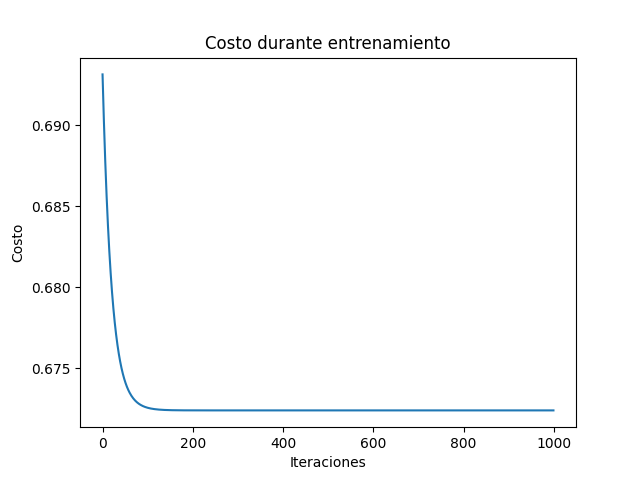

In [16]:
# Inicialización
theta = np.zeros((X_b.shape[1], 1))
lr = 1e-1
num_iter = 1000
cost_history = []

# Gradiente descendente
for i in range(num_iter):
    z = np.dot(X_b, theta)
    h = sigmoid(z)
    
    error = h - y
    grad = np.dot(X_b.T, error) / len(y)
    theta = theta - lr * grad
    
    # Evitar log(0)
    epsilon = 1e-5
    cost = -(1/len(y)) * np.sum(y*np.log(h+epsilon) + (1-y)*np.log(1-h+epsilon))
    cost_history.append(cost)

print("Theta:\n", theta)
# theta = np.array([[0], [5]])

# Gráfico de costo
plt.figure()
plt.plot(cost_history)
plt.title("Costo durante entrenamiento")
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.show()

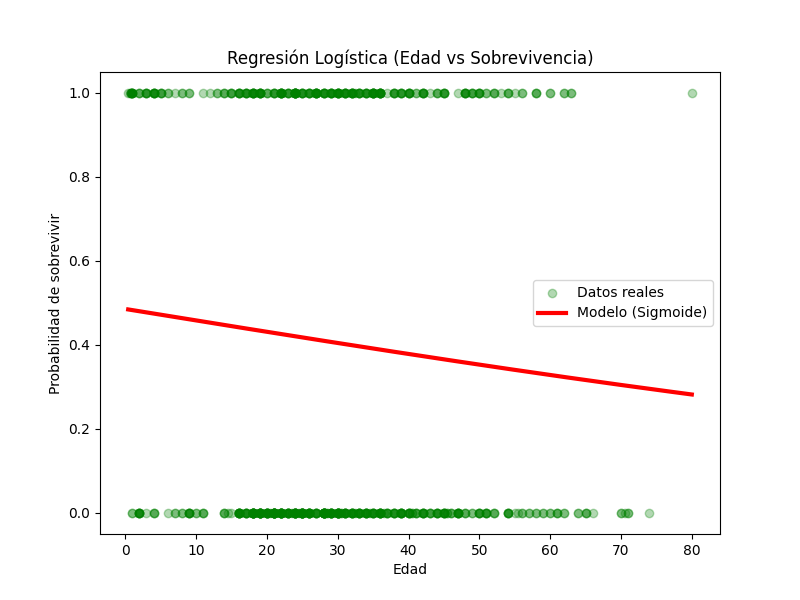

In [17]:
# La edad NO explica bien la supervivencia
# La forma sigmoide depende de la magnitud de los parámetros 
# si la variable independiente no tiene poder predictivo 
# la función se aproxima a una constante.

z = np.dot(X_b, theta)
y_pred = sigmoid(z)

# curva
x_vals = np.linspace(X_original.min(), X_original.max(), 200)
# Normalizar esos valores para el modelo
x_vals_norm = (x_vals - m) / std
x_vals_b = np.c_[np.ones((200,1)), x_vals_norm]
y_vals = sigmoid(np.dot(x_vals_b, theta))

plt.figure(figsize=(8,6))
plt.scatter(X_original, y, alpha=0.3, label="Datos reales", color='green')
# Curva sigmoide
plt.plot(x_vals, y_vals, color='red', linewidth=3, label="Modelo (Sigmoide)")
plt.xlabel("Edad")
plt.ylabel("Probabilidad de sobrevivir")
plt.title("Regresión Logística (Edad vs Sobrevivencia)")
plt.legend()
plt.show()